# Phase 4: Handling Imbalance & Advanced Modeling

Project : MBTI Personality Type Prediction from Text
Dataset : Cleaned output from Phase 2 (mbti_cleaned.csv)

Why this phase matters:
---
Our Phase 3 baseline (Logistic Regression) achieved ~74% average accuracy,
but the minority classes suffer badly.  For instance, E/I accuracy was 74%,
but the model was effectively "guessing Introvert" for borderline cases
because Introverts dominate the dataset (77%).

This phase introduces TWO complementary upgrades:

1. SMOTE (Synthetic Minority Over-sampling Technique)
- Generates synthetic training samples for the minority class
- Applied ONLY to the training set (never the test set)
- Gives the model equal exposure to both classes

2. XGBoost + LightGBM (Gradient Boosted Trees)
- More powerful learners than Logistic Regression
- Built-in support for `scale_pos_weight` (alternative to SMOTE)
- Handle sparse TF-IDF features efficiently
- Regularisation controls overfitting

3. RandomizedSearchCV
- Efficient hyperparameter search (not exhaustive like GridSearch)
- Uses cross-validation for robust estimates
- Optimises for macro-avg F1 (treats both classes equally)

Pipeline:
1. Load cleaned data & create binary targets
2. TF-IDF vectorization
3. For each MBTI axis:
a. Apply SMOTE to training data
b. Train XGBoost with RandomizedSearchCV
c. Train LightGBM with RandomizedSearchCV
d. Compare all 3 approaches (LR baseline, XGB, LGBM)
4. Final comparison summary


In [1]:
%matplotlib inline

In [ ]:
#  Imports 
import os
import time
import warnings
import pickle
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
    make_scorer,
)

from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline

import xgboost as xgb
import lightgbm as lgb

# Suppress noisy warnings for cleaner output
warnings.filterwarnings("ignore", category=UserWarning)
warnings.filterwarnings("ignore", category=FutureWarning)

#  Configuration 
sns.set_theme(style="whitegrid", palette="muted", font_scale=1.15)

DATA_PATH = os.path.join(os.getcwd(), "mbti_cleaned.csv")

MBTI_AXES = [
    ("E_I", 0, "E", "I"),
    ("S_N", 1, "S", "N"),
    ("T_F", 2, "T", "F"),
    ("J_P", 3, "J", "P"),
]

# TF-IDF settings (same as Phase 3 for fair comparison)
MAX_FEATURES = 5000
MAX_DF = 0.95
MIN_DF = 2
NGRAM_RANGE = (1, 2)

# RandomizedSearchCV settings
N_ITER = 10           # Number of random hyperparameter combinations to try
CV_FOLDS = 3          # 3-fold CV (balances speed vs reliability)
RANDOM_STATE = 42
N_JOBS = -1           # Use all CPU cores

# Macro-F1 scorer: treats BOTH classes equally (critical for imbalanced data)
MACRO_F1_SCORER = make_scorer(f1_score, average="macro")

## 1. DATA LOADING & PREPARATION


In [3]:
def load_and_prepare(path: str = DATA_PATH):
    """Load cleaned data, create binary targets, drop empty rows."""
    df = pd.read_csv(path)
    df = df.dropna(subset=["clean_posts"])
    df = df[df["clean_posts"].str.strip() != ""]
    df = df.reset_index(drop=True)

    for axis_name, pos, label_0, label_1 in MBTI_AXES:
        df[axis_name] = (df["type"].str[pos] == label_1).astype(int)

    print("=" * 60)
    print("  PHASE 4: ADVANCED MODELING WITH IMBALANCE HANDLING")
    print("=" * 60)
    print(f"  Dataset: {len(df)} rows")
    return df

## 2. TF-IDF VECTORIZATION


In [4]:
def build_tfidf(X_train_text, X_test_text):
    """Fit TF-IDF on training text, transform both sets."""
    tfidf = TfidfVectorizer(
        max_features=MAX_FEATURES,
        ngram_range=NGRAM_RANGE,
        max_df=MAX_DF,
        min_df=MIN_DF,
        sublinear_tf=True,
        strip_accents="unicode",
    )
    X_train = tfidf.fit_transform(X_train_text)
    X_test  = tfidf.transform(X_test_text)
    print(f"\n  TF-IDF: {X_train.shape[1]} features, "
          f"train={X_train.shape[0]}, test={X_test.shape[0]}")
    return tfidf, X_train, X_test

## 3. SMOTE APPLICATION


In [ ]:
def apply_smote(X_train, y_train, axis_name):
    """
    Apply SMOTE to generate synthetic minority-class samples.
    SMOTE works by:
        1. Picking a minority-class sample
        2. Finding its k nearest neighbours (also minority-class)
        3. Creating a new sample along the line segment between them

    This is applied ONLY to training data.  The test set stays untouched
    to ensure honest evaluation.
    """
    before_counts = pd.Series(y_train).value_counts()
    
    smote = SMOTE(random_state=RANDOM_STATE)
    X_resampled, y_resampled = smote.fit_resample(X_train, y_train)
    
    after_counts = pd.Series(y_resampled).value_counts()
    
    print(f"\n  SMOTE applied for {axis_name}:")
    print(f"    Before: class 0={before_counts.get(0,0)}, class 1={before_counts.get(1,0)} "
          f"(total={len(y_train)})")
    print(f"    After:  class 0={after_counts.get(0,0)}, class 1={after_counts.get(1,0)} "
          f"(total={len(y_resampled)})")
    
    return X_resampled, y_resampled

## 4. XGBOOST WITH RANDOMIZED SEARCH


In [ ]:
def get_xgb_param_grid(imbalance_ratio: float) -> dict:
    """
    XGBoost hyperparameter search space.
    The scale_pos_weight parameter is set to the class imbalance ratio
    as a baseline, with nearby values also explored.  This tells XGBoost
    to penalise misclassifying the minority class proportionally more.
    """
    return {
        "n_estimators": [100, 200, 300],
        "max_depth": [3, 4, 5],
        "learning_rate": [0.05, 0.1, 0.2],
        "subsample": [0.7, 0.8, 1.0],
        "colsample_bytree": [0.7, 0.8, 1.0],
        "min_child_weight": [1, 3, 5],
        "gamma": [0, 0.1],
        "reg_alpha": [0, 0.1],
        "reg_lambda": [1, 2],
        # scale_pos_weight: ratio of negative/positive class counts
        # This handles imbalance WITHIN the model itself
        "scale_pos_weight": [1, imbalance_ratio,
                             imbalance_ratio * 1.5],
    }


def train_xgboost(X_train, y_train, X_test, y_test,
                   axis_name, label_0, label_1):
    """
    Train XGBoost with RandomizedSearchCV optimising macro-F1.
    We use SMOTE'd training data here, so the model sees balanced classes.
    The scale_pos_weight is ALSO tuned as a hyperparameter, providing a
    secondary layer of imbalance handling.
    """
    # Calculate imbalance ratio for scale_pos_weight
    n_neg = (y_train == 0).sum()
    n_pos = (y_train == 1).sum()
    imbalance_ratio = max(n_neg / n_pos, n_pos / n_neg)

    model = xgb.XGBClassifier(
        objective="binary:logistic",
        eval_metric="logloss",
        random_state=RANDOM_STATE,
        n_jobs=N_JOBS,
        verbosity=0,
    )

    param_grid = get_xgb_param_grid(imbalance_ratio)

    search = RandomizedSearchCV(
        estimator=model,
        param_distributions=param_grid,
        n_iter=N_ITER,
        scoring=MACRO_F1_SCORER,      # Optimise for MACRO F1
        cv=CV_FOLDS,
        random_state=RANDOM_STATE,
        n_jobs=1,                      # Avoid nested parallelism (model uses all cores)
        verbose=0,
    )

    start = time.time()
    search.fit(X_train, y_train)
    elapsed = time.time() - start

    best_model = search.best_estimator_
    y_pred = best_model.predict(X_test)

    acc = accuracy_score(y_test, y_pred)
    f1_macro = f1_score(y_test, y_pred, average="macro")
    f1_wtd   = f1_score(y_test, y_pred, average="weighted")

    print(f"\n  XGBoost results for {axis_name} ({label_0} vs {label_1}):")
    print(f"    Best CV macro-F1 : {search.best_score_:.4f}")
    print(f"    Test accuracy    : {acc:.4f}")
    print(f"    Test macro-F1    : {f1_macro:.4f}")
    print(f"    Test weighted-F1 : {f1_wtd:.4f}")
    print(f"    Search time      : {elapsed:.1f}s")
    print(f"    Best params      : {search.best_params_}")

    report = classification_report(y_test, y_pred,
                                   target_names=[label_0, label_1], digits=4)
    print(f"\n    Classification Report:")
    for line in report.split("\n"):
        print(f"      {line}")

    return best_model, {
        "accuracy": acc,
        "f1_macro": f1_macro,
        "f1_weighted": f1_wtd,
        "y_pred": y_pred,
        "best_params": search.best_params_,
        "cv_score": search.best_score_,
    }

## 5. LIGHTGBM WITH RANDOMIZED SEARCH


In [7]:
def get_lgbm_param_grid(imbalance_ratio: float) -> dict:
    """LightGBM hyperparameter search space."""
    return {
        "n_estimators": [100, 200, 300],
        "max_depth": [3, 5, -1],                # -1 = no limit
        "learning_rate": [0.05, 0.1, 0.2],
        "num_leaves": [15, 31, 63],
        "subsample": [0.7, 0.8, 1.0],
        "colsample_bytree": [0.7, 0.8, 1.0],
        "min_child_samples": [10, 20, 50],
        "reg_alpha": [0, 0.1, 0.5],
        "reg_lambda": [0, 1, 5],
        "scale_pos_weight": [1, imbalance_ratio,
                             imbalance_ratio * 1.5],
    }


def train_lightgbm(X_train, y_train, X_test, y_test,
                    axis_name, label_0, label_1):
    """
    Train LightGBM with RandomizedSearchCV optimising macro-F1.

    LightGBM is typically faster than XGBoost on large datasets and
    handles sparse features (like TF-IDF) very efficiently.
    """
    n_neg = (y_train == 0).sum()
    n_pos = (y_train == 1).sum()
    imbalance_ratio = max(n_neg / n_pos, n_pos / n_neg)

    model = lgb.LGBMClassifier(
        objective="binary",
        random_state=RANDOM_STATE,
        n_jobs=N_JOBS,
        verbose=-1,
    )

    param_grid = get_lgbm_param_grid(imbalance_ratio)

    search = RandomizedSearchCV(
        estimator=model,
        param_distributions=param_grid,
        n_iter=N_ITER,
        scoring=MACRO_F1_SCORER,
        cv=CV_FOLDS,
        random_state=RANDOM_STATE,
        n_jobs=1,                      # Avoid nested parallelism
        verbose=0,
    )

    start = time.time()
    search.fit(X_train, y_train)
    elapsed = time.time() - start

    best_model = search.best_estimator_
    y_pred = best_model.predict(X_test)

    acc = accuracy_score(y_test, y_pred)
    f1_macro = f1_score(y_test, y_pred, average="macro")
    f1_wtd   = f1_score(y_test, y_pred, average="weighted")

    print(f"\n  LightGBM results for {axis_name} ({label_0} vs {label_1}):")
    print(f"    Best CV macro-F1 : {search.best_score_:.4f}")
    print(f"    Test accuracy    : {acc:.4f}")
    print(f"    Test macro-F1    : {f1_macro:.4f}")
    print(f"    Test weighted-F1 : {f1_wtd:.4f}")
    print(f"    Search time      : {elapsed:.1f}s")
    print(f"    Best params      : {search.best_params_}")

    report = classification_report(y_test, y_pred,
                                   target_names=[label_0, label_1], digits=4)
    print(f"\n    Classification Report:")
    for line in report.split("\n"):
        print(f"      {line}")

    return best_model, {
        "accuracy": acc,
        "f1_macro": f1_macro,
        "f1_weighted": f1_wtd,
        "y_pred": y_pred,
        "best_params": search.best_params_,
        "cv_score": search.best_score_,
    }

## 6. LOGISTIC REGRESSION BASELINE (for comparison)


In [8]:
def train_lr_baseline(X_train, y_train, X_test, y_test,
                      axis_name, label_0, label_1):
    """Quick LR baseline on SMOTE'd data for fair comparison."""
    model = LogisticRegression(
        max_iter=1000, C=1.0, solver="lbfgs",
        class_weight="balanced", random_state=RANDOM_STATE, n_jobs=N_JOBS,
    )
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    acc = accuracy_score(y_test, y_pred)
    f1_macro = f1_score(y_test, y_pred, average="macro")
    f1_wtd   = f1_score(y_test, y_pred, average="weighted")

    return model, {
        "accuracy": acc,
        "f1_macro": f1_macro,
        "f1_weighted": f1_wtd,
        "y_pred": y_pred,
    }

## 7. VISUALIZATION


In [9]:
def plot_comparison(all_results: dict) -> None:
    """
    Create a grouped bar chart comparing LR, XGBoost, and LightGBM
    across all 4 MBTI axes on 3 metrics: accuracy, macro-F1, weighted-F1.
    """
    fig, axes = plt.subplots(1, 3, figsize=(22, 6))

    metrics = [
        ("accuracy", "Accuracy"),
        ("f1_macro", "Macro-Avg F1 (key metric)"),
        ("f1_weighted", "Weighted-Avg F1"),
    ]

    model_names = ["LR + SMOTE", "XGBoost", "LightGBM"]
    colors = ["#3498DB", "#E74C3C", "#2ECC71"]

    for ax_idx, (metric_key, metric_title) in enumerate(metrics):
        ax = axes[ax_idx]
        x = np.arange(len(MBTI_AXES))
        width = 0.25

        for m_idx, model_name in enumerate(model_names):
            values = []
            for axis_name, _, _, _ in MBTI_AXES:
                val = all_results[axis_name][model_name][metric_key]
                values.append(val)

            bars = ax.bar(x + m_idx * width, values, width,
                          label=model_name, color=colors[m_idx],
                          edgecolor="white", alpha=0.85)

            # Annotate
            for bar in bars:
                ax.text(bar.get_x() + bar.get_width() / 2,
                        bar.get_height() + 0.005,
                        f"{bar.get_height():.3f}",
                        ha="center", fontsize=7, fontweight="bold")

        ax.set_xticks(x + width)
        ax.set_xticklabels([a[0] for a in MBTI_AXES], fontweight="bold")
        ax.set_title(metric_title, fontweight="bold", fontsize=12)
        ax.set_ylabel("Score")
        ax.set_ylim(0, 1.0)
        ax.legend(fontsize=8, loc="lower right")

    plt.suptitle("Phase 4: Model Comparison (LR+SMOTE vs XGBoost vs LightGBM)",
                 fontsize=14, fontweight="bold", y=1.02)
    plt.tight_layout()
    plt.savefig("phase4_model_comparison.png", dpi=150, bbox_inches="tight")
    plt.show()
    print("\n  Chart saved: phase4_model_comparison.png")


def plot_confusion_matrices(all_results: dict) -> None:
    """Plot confusion matrices for the best model per axis."""
    fig, axes = plt.subplots(1, 4, figsize=(22, 5))

    for i, (axis_name, _, label_0, label_1) in enumerate(MBTI_AXES):
        ax = axes[i]
        axis_results = all_results[axis_name]

        # Find the best model by macro-F1
        best_name = max(axis_results, key=lambda k: axis_results[k]["f1_macro"])
        best = axis_results[best_name]

        cm = confusion_matrix(best["y_test"], best["y_pred"])
        cm_pct = cm.astype(float) / cm.sum(axis=1, keepdims=True) * 100

        sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", ax=ax,
                    xticklabels=[label_0, label_1],
                    yticklabels=[label_0, label_1], cbar=False)

        ax.set_title(f"{axis_name}\n{best_name}\nMacro-F1: {best['f1_macro']:.3f}",
                     fontweight="bold", fontsize=10)
        ax.set_xlabel("Predicted")
        ax.set_ylabel("Actual")

        for row in range(2):
            for col in range(2):
                ax.text(col + 0.5, row + 0.75,
                        f"({cm_pct[row][col]:.1f}%)",
                        ha="center", va="center", fontsize=8, color="gray")

    plt.suptitle("Best Model Confusion Matrices (selected by Macro-F1)",
                 fontsize=14, fontweight="bold", y=1.02)
    plt.tight_layout()
    plt.savefig("phase4_best_confusion_matrices.png", dpi=150, bbox_inches="tight")
    plt.show()
    print("  Chart saved: phase4_best_confusion_matrices.png")

## 8. MAIN PIPELINE


In [ ]:
def main():
    """Execute the full Phase 4 advanced modeling pipeline."""

    # Step 1: Load data
    df = load_and_prepare()

    # Step 2: Train/test split (stratified on full 16-class type)
    X_text = df["clean_posts"]
    y_full = df["type"]

    X_train_text, X_test_text, train_idx, test_idx = train_test_split(
        X_text, df.index, test_size=0.20,
        random_state=RANDOM_STATE, stratify=y_full,
    )

    print(f"  Train: {len(X_train_text)} | Test: {len(X_test_text)}")

    # Step 3: TF-IDF
    tfidf, X_train_tfidf, X_test_tfidf = build_tfidf(X_train_text, X_test_text)

    # Step 4: Train all models for each axis
    all_results = {}

    for axis_name, pos, label_0, label_1 in MBTI_AXES:
        print(f"\n{'#' * 60}")
        print(f"  AXIS: {axis_name}  ({label_0} vs {label_1})")
        print(f"{'#' * 60}")

        y_train = df.loc[train_idx, axis_name].values
        y_test  = df.loc[test_idx, axis_name].values

        # -- Apply SMOTE to training data (for LR only) 
        X_train_smote, y_train_smote = apply_smote(
            X_train_tfidf, y_train, axis_name
        )

        # -- Model A: Logistic Regression (SMOTE for imbalance) 
        print("\n  --- Logistic Regression (SMOTE) ---")
        lr_model, lr_results = train_lr_baseline(
            X_train_smote, y_train_smote, X_test_tfidf, y_test,
            axis_name, label_0, label_1,
        )
        lr_results["y_test"] = y_test
        print(f"    Accuracy: {lr_results['accuracy']:.4f} | "
              f"Macro-F1: {lr_results['f1_macro']:.4f}")

        # -- Model B: XGBoost (scale_pos_weight for imbalance) 
        # XGBoost natively handles imbalance via scale_pos_weight, so we
        # train on ORIGINAL data (no SMOTE) -- much faster and avoids
        # synthetic noise from SMOTE on sparse TF-IDF features.
        print("\n  --- XGBoost (scale_pos_weight + RandomizedSearchCV) ---")
        xgb_model, xgb_results = train_xgboost(
            X_train_tfidf, y_train, X_test_tfidf, y_test,
            axis_name, label_0, label_1,
        )
        xgb_results["y_test"] = y_test

        # -- Model C: LightGBM (scale_pos_weight for imbalance) 
        print("\n  --- LightGBM (scale_pos_weight + RandomizedSearchCV) ---")
        lgbm_model, lgbm_results = train_lightgbm(
            X_train_tfidf, y_train, X_test_tfidf, y_test,
            axis_name, label_0, label_1,
        )
        lgbm_results["y_test"] = y_test

        all_results[axis_name] = {
            "LR + SMOTE": lr_results,
            "XGBoost": xgb_results,
            "LightGBM": lgbm_results,
        }

    # Step 5: Final summary
    print("\n" + "=" * 70)
    print("  PHASE 4: FINAL COMPARISON (Macro-Avg F1 -- the key metric)")
    print("=" * 70)
    print(f"  {'Axis':<8s}  {'LR+SMOTE':>12s}  {'XGBoost':>12s}  {'LightGBM':>12s}  {'Best':>12s}")
    print(f"  {'-'*8}  {'-'*12}  {'-'*12}  {'-'*12}  {'-'*12}")

    best_models = {}
    for axis_name, _, _, _ in MBTI_AXES:
        r = all_results[axis_name]
        lr_f1   = r["LR + SMOTE"]["f1_macro"]
        xgb_f1  = r["XGBoost"]["f1_macro"]
        lgbm_f1 = r["LightGBM"]["f1_macro"]

        scores = {"LR+SMOTE": lr_f1, "XGBoost": xgb_f1, "LightGBM": lgbm_f1}
        best_name = max(scores, key=scores.get)
        best_models[axis_name] = best_name

        print(f"  {axis_name:<8s}  {lr_f1:>12.4f}  {xgb_f1:>12.4f}  {lgbm_f1:>12.4f}  "
              f"{best_name:>12s}")

    # Overall averages
    avg_lr   = np.mean([all_results[a]["LR + SMOTE"]["f1_macro"] for a, _, _, _ in MBTI_AXES])
    avg_xgb  = np.mean([all_results[a]["XGBoost"]["f1_macro"] for a, _, _, _ in MBTI_AXES])
    avg_lgbm = np.mean([all_results[a]["LightGBM"]["f1_macro"] for a, _, _, _ in MBTI_AXES])

    print(f"  {'-'*8}  {'-'*12}  {'-'*12}  {'-'*12}  {'-'*12}")
    print(f"  {'AVG':<8s}  {avg_lr:>12.4f}  {avg_xgb:>12.4f}  {avg_lgbm:>12.4f}")
    print("=" * 70)

    # Step 6: Visualize
    plot_comparison(all_results)
    plot_confusion_matrices(all_results)

    print("\n[DONE]  Phase 4 complete -- advanced models trained and compared.")
    print("    Next -> Phase 5: Final Model Selection & Deployment\n")

    return all_results

## Run Phase 4


  PHASE 4: ADVANCED MODELING WITH IMBALANCE HANDLING
  Dataset: 8674 rows
  Train: 6939 | Test: 1735



  TF-IDF: 5000 features, train=6939, test=1735

############################################################
  AXIS: E_I  (E vs I)
############################################################



  SMOTE applied for E_I:
    Before: class 0=1599, class 1=5340 (total=6939)
    After:  class 0=5340, class 1=5340 (total=10680)

  --- Logistic Regression (SMOTE) ---


    Accuracy: 0.7545 | Macro-F1: 0.6727

  --- XGBoost (scale_pos_weight + RandomizedSearchCV) ---



  XGBoost results for E_I (E vs I):
    Best CV macro-F1 : 0.5063
    Test accuracy    : 0.7637
    Test macro-F1    : 0.4991
    Test weighted-F1 : 0.6953
    Search time      : 614.1s
    Best params      : {'subsample': 1.0, 'scale_pos_weight': 1, 'reg_lambda': 1, 'reg_alpha': 0, 'n_estimators': 100, 'min_child_weight': 1, 'max_depth': 4, 'learning_rate': 0.2, 'gamma': 0.1, 'colsample_bytree': 1.0}

    Classification Report:
                    precision    recall  f1-score   support
      
                 E     0.4324    0.0800    0.1350       400
                 I     0.7784    0.9685    0.8632      1335
      
          accuracy                         0.7637      1735
         macro avg     0.6054    0.5243    0.4991      1735
      weighted avg     0.6987    0.7637    0.6953      1735
      

  --- LightGBM (scale_pos_weight + RandomizedSearchCV) ---


...


  LightGBM results for T_F (T vs F):
    Best CV macro-F1 : 0.7590
    Test accuracy    : 0.7700
    Test macro-F1    : 0.7685
    Test weighted-F1 : 0.7700
    Search time      : 281.0s
    Best params      : {'subsample': 0.8, 'scale_pos_weight': 1, 'reg_lambda': 0, 'reg_alpha': 0.1, 'num_leaves': 63, 'n_estimators': 200, 'min_child_samples': 50, 'max_depth': -1, 'learning_rate': 0.05, 'colsample_bytree': 0.7}

    Classification Report:
                    precision    recall  f1-score   support
      
                 T     0.7494    0.7503    0.7498       797
                 F     0.7876    0.7868    0.7872       938
      
          accuracy                         0.7700      1735
         macro avg     0.7685    0.7685    0.7685      1735
      weighted avg     0.7701    0.7700    0.7700      1735
      

############################################################
  AXIS: J_P  (J vs P)
############################################################



  SMOTE applied for J_P:
    Before: class 0=2748, class 1=4191 (total=6939)
    After:  class 0=4191, class 1=4191 (total=8382)

  --- Logistic Regression (SMOTE) ---


    Accuracy: 0.6386 | Macro-F1: 0.6256

  --- XGBoost (scale_pos_weight + RandomizedSearchCV) ---



  XGBoost results for J_P (J vs P):
    Best CV macro-F1 : 0.5586
    Test accuracy    : 0.6133
    Test macro-F1    : 0.5519
    Test weighted-F1 : 0.5866
    Search time      : 628.9s
    Best params      : {'subsample': 1.0, 'scale_pos_weight': 1, 'reg_lambda': 1, 'reg_alpha': 0, 'n_estimators': 100, 'min_child_weight': 1, 'max_depth': 4, 'learning_rate': 0.2, 'gamma': 0.1, 'colsample_bytree': 1.0}

    Classification Report:
                    precision    recall  f1-score   support
      
                 J     0.5184    0.3076    0.3861       686
                 P     0.6423    0.8132    0.7177      1049
      
          accuracy                         0.6133      1735
         macro avg     0.5804    0.5604    0.5519      1735
      weighted avg     0.5933    0.6133    0.5866      1735
      

  --- LightGBM (scale_pos_weight + RandomizedSearchCV) ---



  LightGBM results for J_P (J vs P):
    Best CV macro-F1 : 0.5763
    Test accuracy    : 0.6305
    Test macro-F1    : 0.5869
    Test weighted-F1 : 0.6150
    Search time      : 246.0s
    Best params      : {'subsample': 0.8, 'scale_pos_weight': 1, 'reg_lambda': 5, 'reg_alpha': 0.1, 'num_leaves': 15, 'n_estimators': 200, 'min_child_samples': 50, 'max_depth': 5, 'learning_rate': 0.2, 'colsample_bytree': 1.0}

    Classification Report:
                    precision    recall  f1-score   support
      
                 J     0.5464    0.3863    0.4526       686
                 P     0.6632    0.7903    0.7212      1049
      
          accuracy                         0.6305      1735
         macro avg     0.6048    0.5883    0.5869      1735
      weighted avg     0.6170    0.6305    0.6150      1735
      

  PHASE 4: FINAL COMPARISON (Macro-Avg F1 -- the key metric)
  Axis          LR+SMOTE       XGBoost      LightGBM          Best
  --------  ------------  ------------  -------

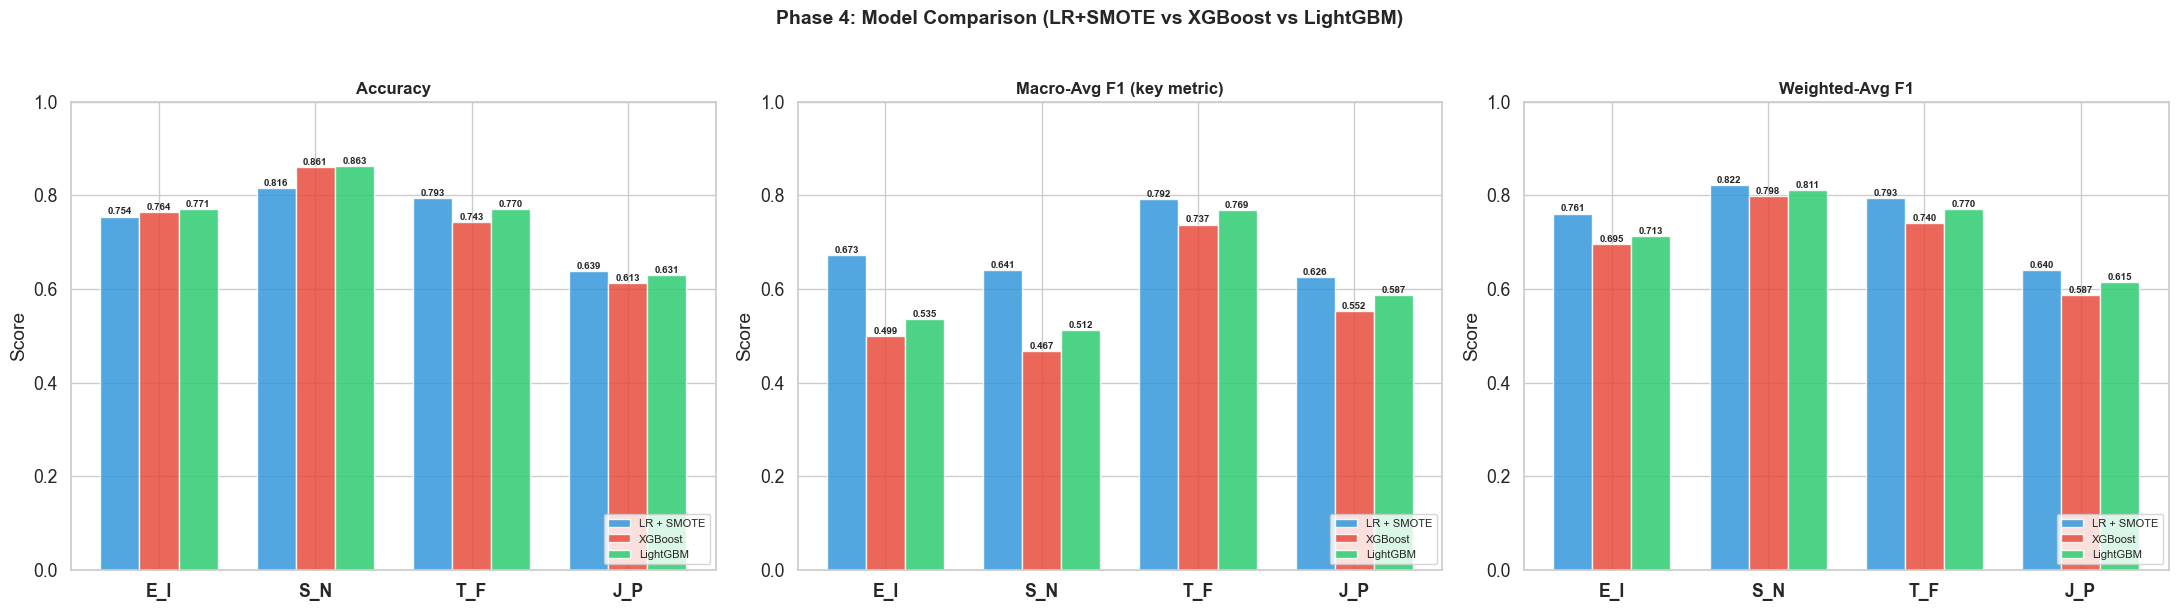


  Chart saved: phase4_model_comparison.png


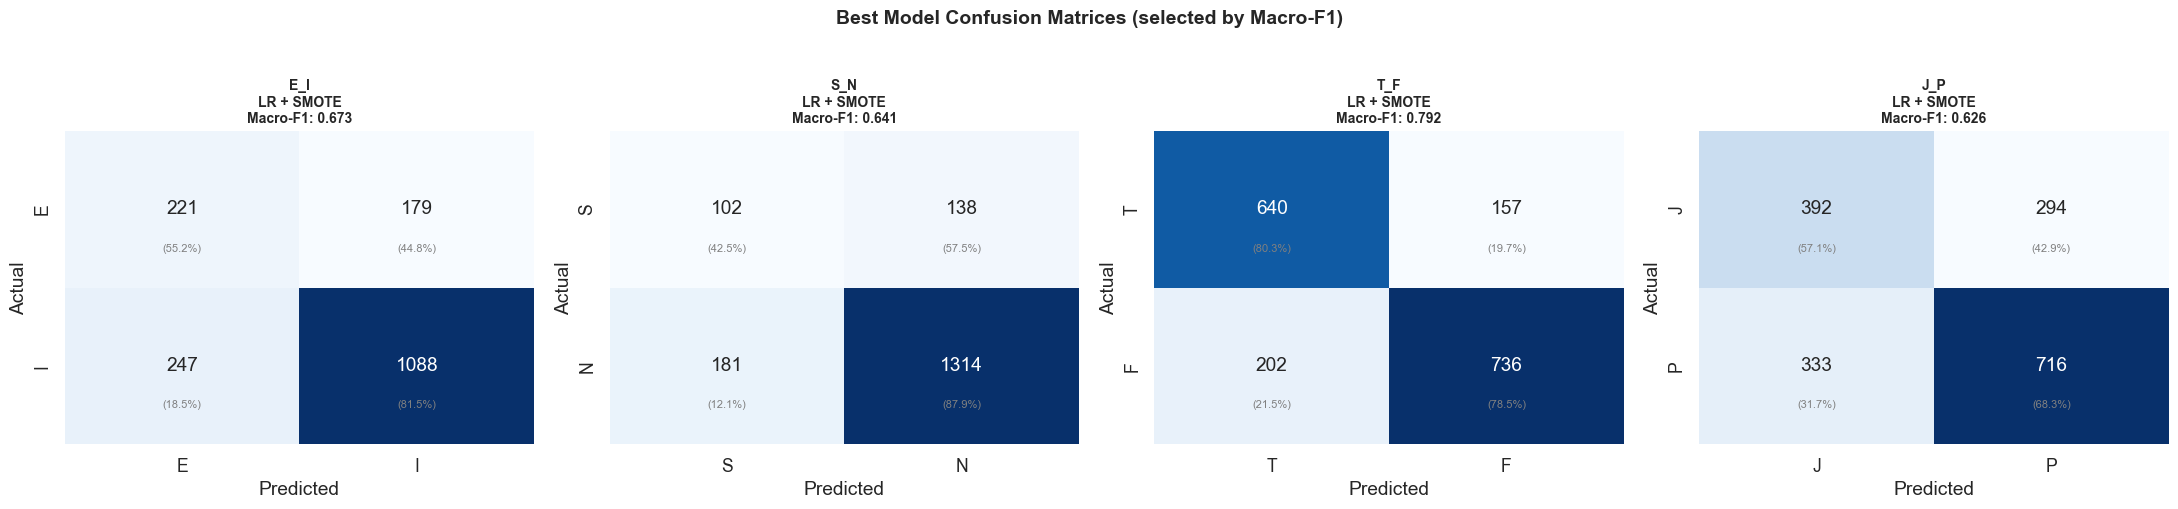

  Chart saved: phase4_best_confusion_matrices.png

[DONE]  Phase 4 complete -- advanced models trained and compared.
    Next -> Phase 5: Final Model Selection & Deployment



In [11]:
all_results = main()